Connected to yp (Python 3.14.1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import warnings
from datetime import datetime
from VegasAfterglow import Fitter, ParamDef, Scale
from VegasAfterglow.units import keV, mJy, hr, sec, Hz, Jy, _c_A
from astropy.cosmology import FlatLambdaCDM
from grb.io import read_data, filter_data
from grb.utils import mJy_to_erg_cm2_s
from grb.const import REDSHIFT, RA, DEC, TRIGGER_TIME, AV, FILTER_INFO

warnings.filterwarnings('ignore', category=FutureWarning) 

In [ ]:
## Environment setup ##
Z = REDSHIFT
RA = RA
DEC = DEC
T0 = TRIGGER_TIME
AV = AV
WAVELENGTH_MAP = FILTER_INFO
C_LIGHT = _c_A / 10  # Speed of light in nm per second

# Current Timestamp
_RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")

# Calculate luminosity distance
cosmo = FlatLambdaCDM(H0=67.66, Om0=0.27) # Use same value from VegasAfterglow
LUMI_DIST = cosmo.luminosity_distance(Z).to('cm').value

# Fitter with model configuration
fitter = Fitter(
    # Source properties
    z=Z,                   # Redshift
    lumi_dist=LUMI_DIST,       # Luminosity distance [cm]

    # Model selection (see sections below for all options)
    jet="tophat",           # Jet structure type
    medium="wind",            # Ambient medium type

    # Physics options
    rvs_shock=False,           # Include reverse shock
    fwd_ssc=False,             # Forward shock inverse Compton
    rvs_ssc=False,            # Reverse shock inverse Compton
    kn=False,                  # Klein-Nishina corrections
    magnetar=False,            # Magnetar energy injection

    # Numerical parameters
    rtol=1e-5,                # Numerical tolerance
    resolution=(0.15, 0.5, 10),  # Grid resolution (phi, theta, t)
)

# Basic parameter set
params = [
    # Jet parameters
    ParamDef("E_iso",   1e50,  1e54,  Scale.log),     # Isotropic energy in erg
    ParamDef("Gamma0",    10,   500,  Scale.log),     # Lorentz factor
    ParamDef("theta_c", 0.01,   0.5,  Scale.linear),  # Opening angle in radians
    ParamDef("theta_v",    0,     0,  Scale.fixed),   # Viewing angle (on-axis) in radians
    # Medium parameters
    # ParamDef("n_ism",   1e-3,   100,  Scale.log),     # Number density in cm^-3
    # Wind medium parameter (replaces n_ism)
    ParamDef("A_star",  1e-3,   1.0,  Scale.log),     # Wind parameter
    # Microphysics parameters
    ParamDef("p",        2.1,   2.8,  Scale.linear),  # Electron spectral index
    ParamDef("eps_e",   1e-3,   0.5,  Scale.log),     # Electron energy fraction
    ParamDef("eps_B",   1e-5,   0.1,  Scale.log),     # Magnetic energy fraction
    ParamDef("xi_e",     0.1,   1.0,  Scale.linear),  # Fraction of accelerated electrons
    # Jet duration (important for reverse shock)
    # ParamDef("tau",        1,   1e6,  Scale.log),     # Jet duration in seconds
    # # Reverse shock microphysics (can be different)
    # ParamDef("p_r",      2.1,   2.8,  Scale.linear),
    # ParamDef("eps_e_r", 1e-3,   0.5,  Scale.log),
    # ParamDef("eps_B_r", 1e-5,   0.1,  Scale.log),
    # ParamDef("xi_e_r",   0.1,   1.0,  Scale.linear),
    # Magnetar parameters (if magnetar=True)
    # ParamDef("B",        1e15,  1e16, Scale.log),     # Magnetic field strength in G
    # ParamDef("P",        0.5,   1.0,  Scale.linear),  # Period in seconds
    # ParamDef("Mdot",     1e14,  1e16, Scale.log),     # Mass accretion rate in g/s
]

In [ ]:
## Data preparation ##

# XRT lightcurve #
XRT_NU_MIN = 0.3 * keV  # VegasAfterglow convert automatically to Hz
XRT_NU_MAX = 10 * keV  # VegasAfterglow convert automatically to Hz
XRT_NU = 10 * keV  # VegasAfterglow convert automatically to Hz
xrt_data = read_data("xrt")
# xrt_data = read_data("xrt_unabsorb")

filtered_xrt_data = filter_data(xrt_data, exclude_time_range = (3e3,  1e4)) # Exclude flare

xrt_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(filtered_xrt_data["Flux_high"], filtered_xrt_data["Flux_low"])])
# # Debug check for XRT
# xrt_zero_mask = (xrt_err == 0.0) | np.isnan(xrt_err)
# if np.any(xrt_zero_mask):
#     print(f"WARNING: Found {np.sum(xrt_zero_mask)} XRT points with 0.0 error!")
#     print(filtered_xrt_data.loc[xrt_zero_mask, ["Time", "Flux", "Flux_high", "Flux_low"]])

fitter.add_flux(band=(XRT_NU_MIN, XRT_NU_MAX),
                t=filtered_xrt_data["Time"] * sec,
                flux=filtered_xrt_data["Flux"], # erg/cm^2/s
                err=xrt_err, # erg/cm^2/s
                weights=None)  # All quantities in CGS units

# fitter.add_flux_density(nu=XRT_NU,
#                 t=filtered_xrt_data["Time"] * sec,
#                 f_nu=filtered_xrt_data["Flux"] * Jy, err=xrt_err * Jy,
#                 weights=None)  # All quantities in CGS units
print("XRT data added")

# 7DT SED #
sdt_data = read_data("sdt_pivot", correct_galactic_extinction=True, correct_host_extinction=True, 
                     host_av=AV, host_z=Z, add_converted_flux=True)
sdt_time = sdt_data["date_obs"].iloc[0]
sdt_from_t0 = datetime.strptime(sdt_time, '%Y-%m-%dT%H:%M:%S.%f') - T0
SDT_SECONDS = sdt_from_t0.total_seconds()
fitter.add_spectrum(t=SDT_SECONDS * sec, 
                    nu=sdt_data["frequency_Hz"] * Hz,
                    f_nu=sdt_data["flux_mJy"]* mJy, # erg/cm^2/s/Hz
                    err=sdt_data["flux_error_mJy"]* mJy)  # All quantities in CGS units
print("7DT SED added")

# GCN Circular #
circular_data = read_data("circular_wavelength", correct_galactic_extinction=True, correct_host_extinction=True, 
                     host_av=AV, host_z=Z, add_converted_flux=True)

select_circular_data = [
    filter_data(circular_data, filter_name="g", facility_name="7DT", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),
    filter_data(circular_data, filter_name="r'", facility_name="OHP/T193", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),
    filter_data(circular_data, filter_name="i", facility_name="NUTTelA-TAO", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),
    filter_data(circular_data, filter_name="Ic", facility_name="Leavitt", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),
    filter_data(circular_data, filter_name="Rc", facility_name="Leavitt", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),
    filter_data(circular_data, filter_name="V", facility_name="OsservatorioAstronomicoNastroVerde", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),
    filter_data(circular_data, filter_name="J", facility_name="SYSU", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),
    filter_data(circular_data, filter_name="clear", facility_name="Calapai", remove_upper_limits=True, exclude_time_range=(50, float('inf')))
]

for data in select_circular_data:
    if data.empty:
        print("Empty data, skipping...")
        continue
    # # Debug check for Optical data
    # err_array = data["flux_error_mJy"].to_numpy()
    # opt_zero_mask = (err_array == 0.0) | np.isnan(err_array)
    # if np.any(opt_zero_mask):
    #     # Using columns you likely have based on your filtering function
    #     print(f"WARNING: Found {np.sum(opt_zero_mask)} points with 0.0 error!")
    #     print(data.loc[opt_zero_mask, ["Facility","Filter","Time", "flux_mJy", "flux_error_mJy"]])
    # data_min_freq = data["frequency_Hz"].iloc[0] - data["frequency_error_Hz"].iloc[0]
    # data_max_freq = data["frequency_Hz"].iloc[0] + data["frequency_error_Hz"].iloc[0]
    # fitter.add_flux(band=(data_min_freq, data_max_freq),
    #                 t=data["Time"].to_numpy() * hr,
    #                 flux=data["flux_mJy"].to_numpy() * mJy,
    #                 err=data["flux_error_mJy"].to_numpy() * mJy,
    #                 weights=None)  # All quantities in CGS units
    
    fitter.add_flux_density(nu=data["frequency_Hz"].iloc[0],
                    t=data["Time"].to_numpy() * hr,
                    f_nu=data["flux_mJy"].to_numpy() * mJy,
                    err=data["flux_error_mJy"].to_numpy() * mJy,
                    weights=None)  # All quantities in CGS units
    print(f"GCN Circular data added for {data['Filter'].iloc[0]} filter - {len(data)} points")

XRT data added
7DT SED added
GCN Circular data added for g filter - 1 points
GCN Circular data added for r' filter - 2 points
GCN Circular data added for i filter - 8 points
GCN Circular data added for Ic filter - 18 points
GCN Circular data added for Rc filter - 35 points
GCN Circular data added for V filter - 4 points
GCN Circular data added for J filter - 2 points
GCN Circular data added for clear filter - 40 points


NameError: name 'BAND_STYLE' is not defined

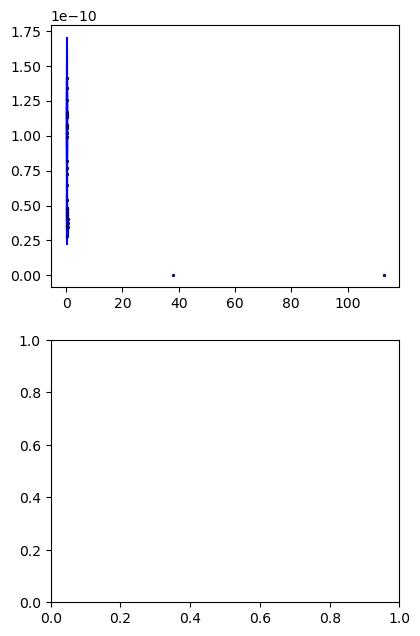

In [ ]:
fig = plt.figure(figsize=(4.5, 7.5))
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

# Observed XRT (approximate flux density for display)
ax1.errorbar(filtered_xrt_data["Time"]/3600, # hours
                filtered_xrt_data["Flux"], xrt_err, # erg/cm^2/sec
                fmt=".", color="blue", markersize=4,
                markeredgecolor="k", markeredgewidth=0.4, label="XRT")

# Observed optical (GCN circulars) — only bands that have a model curve
for data in select_circular_data:
    wave = data["wavelength"].iloc[0]
    freq = data["frequency_Hz"].iloc[0]
    if wave not in BAND_STYLE:
        print(f"Skipping {data['Filter'].iloc[0]}/{wave:.2e} A filter - not in BAND_STYLE")
        continue
    color, label = BAND_STYLE[wave]
    ax1.errorbar(data["Time"].to_numpy(), # hours
                    mJy_to_erg_cm2_s(data["flux_mJy"].to_numpy(), freq), mJy_to_erg_cm2_s(data["flux_error_mJy"].to_numpy(), freq), # erg/cm^2/sec
                    fmt=".", color=color, markersize=4,
                    markeredgecolor="k", markeredgewidth=0.4, label=f"{label}")
# ax1.set_xlim(LC_T_RANGE.min()/3600, LC_T_RANGE.max()/3600)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("t [h]")
ax1.set_ylabel(r"$F_\nu$ [erg/cm$^2$/s]")
ax1.set_title("Light Curve Fitting")
ax1.legend(fontsize=7)

# ── Spectrum panel
freq = sdt_data["frequency_Hz"]
# ax2.errorbar(freq, # Hz
#              mJy_to_erg_cm2_s(sdt_data["flux_mJy"], freq), mJy_to_erg_cm2_s(sdt_data["flux_error_mJy"], freq), # erg/cm^2/s
#              fmt="o", color="purple", markersize=5,
#              markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")
ax2.errorbar(freq, # Hz
            sdt_data["flux_mJy"] * mJy, sdt_data["flux_error_mJy"] * mJy, # erg/cm^2/s
            fmt="o", color="purple", markersize=5,
            markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")

ax2.set_xscale("log")
ax2.set_yscale("log")

ax2.set_xlabel(r"$\nu$ [Hz]")
# ax2.set_ylabel(r"$F_\nu$ [erg/cm$^2$/s]")
ax2.set_ylabel(r"$F_\nu$ [erg/cm$^2$/s/Hz]")
ax2.set_title(f"7DT SED at t={SDT_SECONDS:.0f} s")
ax2.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
## Environment setup ##
Z = REDSHIFT
RA = RA
DEC = DEC
T0 = TRIGGER_TIME
AV = AV
WAVELENGTH_MAP = FILTER_INFO
C_LIGHT = _c_A / 10  # Speed of light in nm per second

# Current Timestamp
_RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")

# Calculate luminosity distance
cosmo = FlatLambdaCDM(H0=67.66, Om0=0.27) # Use same value from VegasAfterglow
LUMI_DIST = cosmo.luminosity_distance(Z).to('cm').value

# Band style for plotting
BAND_STYLE = {
    XRT_NU:                                                      ("black",      "X-ray"),
    C_LIGHT / WAVELENGTH_MAP["g"]["central_wavelength_nm"]:      ("teal",       "g"),
    C_LIGHT / WAVELENGTH_MAP["r"]["central_wavelength_nm"]:      ("crimson",    "r"),
    C_LIGHT / WAVELENGTH_MAP["i"]["central_wavelength_nm"]:      ("darkviolet", "i"),
    C_LIGHT / WAVELENGTH_MAP["Ic"]["central_wavelength_nm"]:     ("indigo",     "Ic"),
    C_LIGHT / WAVELENGTH_MAP["Rc"]["central_wavelength_nm"]:     ("orangered",  "Rc"),
    C_LIGHT / WAVELENGTH_MAP["V"]["central_wavelength_nm"]:      ("forestgreen","V"),
    C_LIGHT / WAVELENGTH_MAP["J"]["central_wavelength_nm"]:      ("saddlebrown","J"),
    C_LIGHT / WAVELENGTH_MAP["clear"]["central_wavelength_nm"]:  ("darkgrey",   "clear"),
}

# Fitter with model configuration
fitter = Fitter(
    # Source properties
    z=Z,                   # Redshift
    lumi_dist=LUMI_DIST,       # Luminosity distance [cm]

    # Model selection (see sections below for all options)
    jet="tophat",           # Jet structure type
    medium="wind",            # Ambient medium type

    # Physics options
    rvs_shock=False,           # Include reverse shock
    fwd_ssc=False,             # Forward shock inverse Compton
    rvs_ssc=False,            # Reverse shock inverse Compton
    kn=False,                  # Klein-Nishina corrections
    magnetar=False,            # Magnetar energy injection

    # Numerical parameters
    rtol=1e-5,                # Numerical tolerance
    resolution=(0.15, 0.5, 10),  # Grid resolution (phi, theta, t)
)

# Basic parameter set
params = [
    # Jet parameters
    ParamDef("E_iso",   1e50,  1e54,  Scale.log),     # Isotropic energy in erg
    ParamDef("Gamma0",    10,   500,  Scale.log),     # Lorentz factor
    ParamDef("theta_c", 0.01,   0.5,  Scale.linear),  # Opening angle in radians
    ParamDef("theta_v",    0,     0,  Scale.fixed),   # Viewing angle (on-axis) in radians
    # Medium parameters
    # ParamDef("n_ism",   1e-3,   100,  Scale.log),     # Number density in cm^-3
    # Wind medium parameter (replaces n_ism)
    ParamDef("A_star",  1e-3,   1.0,  Scale.log),     # Wind parameter
    # Microphysics parameters
    ParamDef("p",        2.1,   2.8,  Scale.linear),  # Electron spectral index
    ParamDef("eps_e",   1e-3,   0.5,  Scale.log),     # Electron energy fraction
    ParamDef("eps_B",   1e-5,   0.1,  Scale.log),     # Magnetic energy fraction
    ParamDef("xi_e",     0.1,   1.0,  Scale.linear),  # Fraction of accelerated electrons
    # Jet duration (important for reverse shock)
    # ParamDef("tau",        1,   1e6,  Scale.log),     # Jet duration in seconds
    # # Reverse shock microphysics (can be different)
    # ParamDef("p_r",      2.1,   2.8,  Scale.linear),
    # ParamDef("eps_e_r", 1e-3,   0.5,  Scale.log),
    # ParamDef("eps_B_r", 1e-5,   0.1,  Scale.log),
    # ParamDef("xi_e_r",   0.1,   1.0,  Scale.linear),
    # Magnetar parameters (if magnetar=True)
    # ParamDef("B",        1e15,  1e16, Scale.log),     # Magnetic field strength in G
    # ParamDef("P",        0.5,   1.0,  Scale.linear),  # Period in seconds
    # ParamDef("Mdot",     1e14,  1e16, Scale.log),     # Mass accretion rate in g/s
]

Skipping g/4.81e+03 A filter - not in BAND_STYLE
Skipping r'/6.26e+03 A filter - not in BAND_STYLE
Skipping i/7.58e+03 A filter - not in BAND_STYLE
Skipping Ic/7.99e+03 A filter - not in BAND_STYLE
Skipping Rc/6.53e+03 A filter - not in BAND_STYLE
Skipping V/5.54e+03 A filter - not in BAND_STYLE
Skipping J/1.24e+04 A filter - not in BAND_STYLE
Skipping clear/5.62e+03 A filter - not in BAND_STYLE


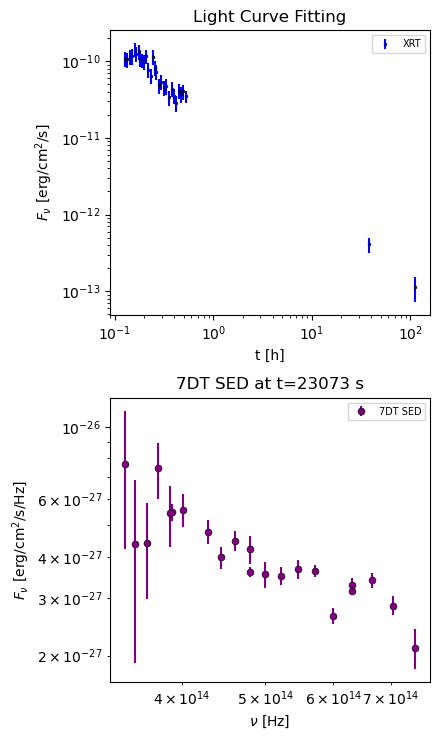

In [ ]:
fig = plt.figure(figsize=(4.5, 7.5))
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

# Observed XRT (approximate flux density for display)
ax1.errorbar(filtered_xrt_data["Time"]/3600, # hours
                filtered_xrt_data["Flux"], xrt_err, # erg/cm^2/sec
                fmt=".", color="blue", markersize=4,
                markeredgecolor="k", markeredgewidth=0.4, label="XRT")

# Observed optical (GCN circulars) — only bands that have a model curve
for data in select_circular_data:
    wave = data["wavelength"].iloc[0]
    freq = data["frequency_Hz"].iloc[0]
    if wave not in BAND_STYLE:
        print(f"Skipping {data['Filter'].iloc[0]}/{wave:.2e} A filter - not in BAND_STYLE")
        continue
    color, label = BAND_STYLE[wave]
    ax1.errorbar(data["Time"].to_numpy(), # hours
                    mJy_to_erg_cm2_s(data["flux_mJy"].to_numpy(), freq), mJy_to_erg_cm2_s(data["flux_error_mJy"].to_numpy(), freq), # erg/cm^2/sec
                    fmt=".", color=color, markersize=4,
                    markeredgecolor="k", markeredgewidth=0.4, label=f"{label}")
# ax1.set_xlim(LC_T_RANGE.min()/3600, LC_T_RANGE.max()/3600)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("t [h]")
ax1.set_ylabel(r"$F_\nu$ [erg/cm$^2$/s]")
ax1.set_title("Light Curve Fitting")
ax1.legend(fontsize=7)

# ── Spectrum panel
freq = sdt_data["frequency_Hz"]
# ax2.errorbar(freq, # Hz
#              mJy_to_erg_cm2_s(sdt_data["flux_mJy"], freq), mJy_to_erg_cm2_s(sdt_data["flux_error_mJy"], freq), # erg/cm^2/s
#              fmt="o", color="purple", markersize=5,
#              markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")
ax2.errorbar(freq, # Hz
            sdt_data["flux_mJy"] * mJy, sdt_data["flux_error_mJy"] * mJy, # erg/cm^2/s
            fmt="o", color="purple", markersize=5,
            markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")

ax2.set_xscale("log")
ax2.set_yscale("log")

ax2.set_xlabel(r"$\nu$ [Hz]")
# ax2.set_ylabel(r"$F_\nu$ [erg/cm$^2$/s]")
ax2.set_ylabel(r"$F_\nu$ [erg/cm$^2$/s/Hz]")
ax2.set_title(f"7DT SED at t={SDT_SECONDS:.0f} s")
ax2.legend(fontsize=7)

plt.tight_layout()
plt.show()

Skipping g/4.81e+03 A filter - not in BAND_STYLE
Skipping r'/6.26e+03 A filter - not in BAND_STYLE
Skipping i/7.58e+03 A filter - not in BAND_STYLE
Skipping Rc/6.53e+03 A filter - not in BAND_STYLE
Skipping V/5.54e+03 A filter - not in BAND_STYLE
Skipping J/1.24e+04 A filter - not in BAND_STYLE
Skipping clear/5.62e+03 A filter - not in BAND_STYLE


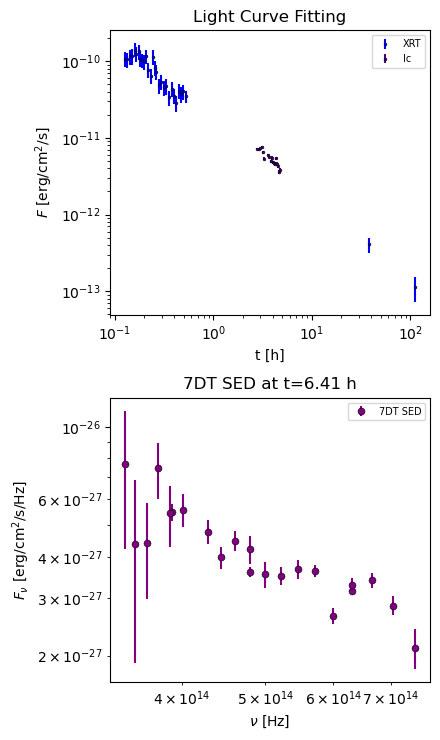

In [ ]:
    fig = plt.figure(figsize=(4.5, 7.5))
    ax1 = fig.add_subplot(211)
    ax2 = fig.add_subplot(212)

    # Observed XRT (approximate flux density for display)
    ax1.errorbar(filtered_xrt_data["Time"]/3600, # hours
                 filtered_xrt_data["Flux"], xrt_err, # erg/cm^2/sec
                 fmt=".", color="blue", markersize=4,
                 markeredgecolor="k", markeredgewidth=0.4, label="XRT")

    # Observed optical (GCN circulars) — only bands that have a model curve
    for data in select_circular_data:
        if data.empty:
            print(f"Skipping empty data - {data}")
            continue
        wave = data["wavelength"].iloc[0]
        freq = data["frequency_Hz"].iloc[0]
        if freq not in BAND_STYLE:
            print(f"Skipping {data['Filter'].iloc[0]}/{wave:.2e} A filter - not in BAND_STYLE")
            continue
        color, label = BAND_STYLE[freq]
        ax1.errorbar(data["Time"].to_numpy(), # hours
                     mJy_to_erg_cm2_s(data["flux_mJy"].to_numpy(), freq), mJy_to_erg_cm2_s(data["flux_error_mJy"].to_numpy(), freq), # erg/cm^2/sec
                     fmt=".", color=color, markersize=4,
                     markeredgecolor="k", markeredgewidth=0.4, label=f"{label}")
        
    # ax1.set_xlim(LC_T_RANGE.min()/3600, LC_T_RANGE.max()/3600)
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    
    ax1.set_xlabel("t [h]")
    ax1.set_ylabel(r"$F$ [erg/cm$^2$/s]")
    ax1.set_title("Light Curve Fitting")
    ax1.legend(fontsize=7)

    # ── Spectrum panel
    freq = sdt_data["frequency_Hz"]
    # ax2.errorbar(freq, # Hz
    #              mJy_to_erg_cm2_s(sdt_data["flux_mJy"], freq), mJy_to_erg_cm2_s(sdt_data["flux_error_mJy"], freq), # erg/cm^2/s
    #              fmt="o", color="purple", markersize=5,
    #              markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")
    ax2.errorbar(freq, # Hz
                sdt_data["flux_mJy"] * mJy, sdt_data["flux_error_mJy"] * mJy, # erg/cm^2/s
                fmt="o", color="purple", markersize=5,
                markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")
    
    # ax2.set_xlim(SPEC_F_RANGE.min(), SPEC_F_RANGE.max())
    ax2.set_xscale("log")
    ax2.set_yscale("log")

    ax2.set_xlabel(r"$\nu$ [Hz]")   
    # ax2.set_ylabel(r"$F$ [erg/cm$^2$/s]")
    ax2.set_ylabel(r"$F_\nu$ [erg/cm$^2$/s/Hz]")
    ax2.set_title(f"7DT SED at t={SDT_SECONDS/3600:.2f} h")
    ax2.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


In [ ]:
data["wavelength"].iloc[0]

np.float64(5622.12)

In [ ]:
SPEC_F_RANGE

NameError: name 'SPEC_F_RANGE' is not defined

In [ ]:
## Environment setup ##
Z = REDSHIFT
RA = RA
DEC = DEC
T0 = TRIGGER_TIME
AV = AV
WAVELENGTH_MAP = FILTER_INFO
C_LIGHT = _c_A / 10  # Speed of light in nm per second

# Current Timestamp
_RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")

# XRT energy range
XRT_NU_MIN = 0.3 * keV  # VegasAfterglow convert automatically to Hz
XRT_NU_MAX = 10 * keV  # VegasAfterglow convert automatically to Hz
XRT_NU = 10 * keV  # VegasAfterglow convert automatically to Hz

# Calculate luminosity distance
cosmo = FlatLambdaCDM(H0=67.66, Om0=0.27) # Use same value from VegasAfterglow
LUMI_DIST = cosmo.luminosity_distance(Z).to('cm').value

# Generate model light curves and spectrum
LC_T_RANGE    = np.logspace(2, 6, 200)                           # 10 s → 10^6 s
SPEC_F_RANGE  = np.logspace(14, 15, 200)                          # Frequency grid for SED (10^14 to 10^15 Hz)

# Band style for plotting
BAND_STYLE = {
    XRT_NU:                                                      ("black",      "X-ray"),
    C_LIGHT / WAVELENGTH_MAP["g"]["central_wavelength_nm"]:      ("teal",       "g"),
    C_LIGHT / WAVELENGTH_MAP["r"]["central_wavelength_nm"]:      ("crimson",    "r"),
    C_LIGHT / WAVELENGTH_MAP["i"]["central_wavelength_nm"]:      ("darkviolet", "i"),
    C_LIGHT / WAVELENGTH_MAP["Ic"]["central_wavelength_nm"]:     ("indigo",     "Ic"),
    C_LIGHT / WAVELENGTH_MAP["Rc"]["central_wavelength_nm"]:     ("orangered",  "Rc"),
    C_LIGHT / WAVELENGTH_MAP["V"]["central_wavelength_nm"]:      ("forestgreen","V"),
    C_LIGHT / WAVELENGTH_MAP["J"]["central_wavelength_nm"]:      ("saddlebrown","J"),
    C_LIGHT / WAVELENGTH_MAP["clear"]["central_wavelength_nm"]:  ("darkgrey",   "clear"),
}

# Fitter with model configuration
fitter = Fitter(
    # Source properties
    z=Z,                   # Redshift
    lumi_dist=LUMI_DIST,       # Luminosity distance [cm]

    # Model selection (see sections below for all options)
    jet="tophat",           # Jet structure type
    medium="wind",            # Ambient medium type

    # Physics options
    rvs_shock=False,           # Include reverse shock
    fwd_ssc=False,             # Forward shock inverse Compton
    rvs_ssc=False,            # Reverse shock inverse Compton
    kn=False,                  # Klein-Nishina corrections
    magnetar=False,            # Magnetar energy injection

    # Numerical parameters
    rtol=1e-5,                # Numerical tolerance
    resolution=(0.15, 0.5, 10),  # Grid resolution (phi, theta, t)
)

# Basic parameter set
params = [
    # Jet parameters
    ParamDef("E_iso",   1e50,  1e54,  Scale.log),     # Isotropic energy in erg
    ParamDef("Gamma0",    10,   500,  Scale.log),     # Lorentz factor
    ParamDef("theta_c", 0.01,   0.5,  Scale.linear),  # Opening angle in radians
    ParamDef("theta_v",    0,     0,  Scale.fixed),   # Viewing angle (on-axis) in radians
    # Medium parameters
    # ParamDef("n_ism",   1e-3,   100,  Scale.log),     # Number density in cm^-3
    # Wind medium parameter (replaces n_ism)
    ParamDef("A_star",  1e-3,   1.0,  Scale.log),     # Wind parameter
    # Microphysics parameters
    ParamDef("p",        2.1,   2.8,  Scale.linear),  # Electron spectral index
    ParamDef("eps_e",   1e-3,   0.5,  Scale.log),     # Electron energy fraction
    ParamDef("eps_B",   1e-5,   0.1,  Scale.log),     # Magnetic energy fraction
    ParamDef("xi_e",     0.1,   1.0,  Scale.linear),  # Fraction of accelerated electrons
    # Jet duration (important for reverse shock)
    # ParamDef("tau",        1,   1e6,  Scale.log),     # Jet duration in seconds
    # # Reverse shock microphysics (can be different)
    # ParamDef("p_r",      2.1,   2.8,  Scale.linear),
    # ParamDef("eps_e_r", 1e-3,   0.5,  Scale.log),
    # ParamDef("eps_B_r", 1e-5,   0.1,  Scale.log),
    # ParamDef("xi_e_r",   0.1,   1.0,  Scale.linear),
    # Magnetar parameters (if magnetar=True)
    # ParamDef("B",        1e15,  1e16, Scale.log),     # Magnetic field strength in G
    # ParamDef("P",        0.5,   1.0,  Scale.linear),  # Period in seconds
    # ParamDef("Mdot",     1e14,  1e16, Scale.log),     # Mass accretion rate in g/s
]

In [ ]:
def draw_bestfit(lc_model=None, lc_bands=None, spec_model=None, save=True):
    """
    lc_model     : shape [n_bands, n_t] from flux_density_grid
    lc_bands     : 1-D frequency array [Hz] matching lc_model rows
    spec_model   : shape [n_nu, 1] from flux_density_grid at t_spec_sec
    """
    fig = plt.figure(figsize=(4.5, 7.5))
    ax1 = fig.add_subplot(211)
    ax2 = fig.add_subplot(212)

    # ── Light-curve panel: model curves
    if lc_model is not None:
        for i, nu in enumerate(lc_bands):
            color, label = BAND_STYLE.get(nu, ("grey", f"{nu:.2e} Hz"))
            ax1.plot(LC_T_RANGE/3600, lc_model[i], "-", color=color, lw=1.5, label=f"model {label}")

    # Observed XRT (approximate flux density for display)
    ax1.errorbar(filtered_xrt_data["Time"]/3600, # hours
                 filtered_xrt_data["Flux"], xrt_err, # erg/cm^2/sec
                 fmt=".", color="blue", markersize=4,
                 markeredgecolor="k", markeredgewidth=0.4, label="XRT")

    # Observed optical (GCN circulars) — only bands that have a model curve
    for data in select_circular_data:
        if data.empty:
            print(f"Skipping empty data - {data}")
            continue
        wave = data["wavelength"].iloc[0]
        freq = data["frequency_Hz"].iloc[0]
        if freq not in BAND_STYLE:
            print(f"Skipping {data['Filter'].iloc[0]}/{wave:.3e} A filter - not in BAND_STYLE")
            continue
        color, label = BAND_STYLE[freq]
        ax1.errorbar(data["Time"].to_numpy(), # hours
                     mJy_to_erg_cm2_s(data["flux_mJy"].to_numpy(), freq), mJy_to_erg_cm2_s(data["flux_error_mJy"].to_numpy(), freq), # erg/cm^2/sec
                     fmt=".", color=color, markersize=4,
                     markeredgecolor="k", markeredgewidth=0.4, label=f"{label}")
        
    # ax1.set_xlim(LC_T_RANGE.min()/3600, LC_T_RANGE.max()/3600)
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    
    ax1.set_xlabel("t [h]")
    ax1.set_ylabel(r"$F$ [erg/cm$^2$/s]")
    ax1.set_title("Light Curve Fitting")
    ax1.legend(fontsize=7)

    # ── Spectrum panel
    if spec_model is not None:
        ax2.plot(SPEC_F_RANGE, spec_model[:, 0], "-", color="k", lw=1.5,
                label=f"model at t={SDT_SECONDS/3600:.2f} h")
    
    # 7DT SED
    freq = sdt_data["frequency_Hz"]
    # ax2.errorbar(freq, # Hz
    #              mJy_to_erg_cm2_s(sdt_data["flux_mJy"], freq), mJy_to_erg_cm2_s(sdt_data["flux_error_mJy"], freq), # erg/cm^2/s
    #              fmt="o", color="purple", markersize=5,
    #              markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")
    ax2.errorbar(freq, # Hz
                sdt_data["flux_mJy"] * mJy, sdt_data["flux_error_mJy"] * mJy, # erg/cm^2/s
                fmt="o", color="purple", markersize=5,
                markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")
    
    # ax2.set_xlim(SPEC_F_RANGE.min(), SPEC_F_RANGE.max())
    ax2.set_xscale("log")
    ax2.set_yscale("log")

    ax2.set_xlabel(r"$\nu$ [Hz]")   
    # ax2.set_ylabel(r"$F$ [erg/cm$^2$/s]")
    ax2.set_ylabel(r"$F_\nu$ [erg/cm$^2$/s/Hz]")
    ax2.set_title(f"7DT SED at t={SDT_SECONDS/3600:.2f} h")
    ax2.legend(fontsize=7)

    plt.tight_layout()
    if save:
        plt.savefig(f"bestfit_{_RUN_TS}_wind.png", dpi=300, bbox_inches="tight")
        print(f"Best fit plot saved as bestfit_{_RUN_TS}_wind.png")
    else:
        plt.show()

Skipping g/4.806e+03 A filter - not in BAND_STYLE
Skipping r'/6.258e+03 A filter - not in BAND_STYLE
Skipping i/7.581e+03 A filter - not in BAND_STYLE
Skipping Rc/6.534e+03 A filter - not in BAND_STYLE
Skipping V/5.538e+03 A filter - not in BAND_STYLE
Skipping J/1.235e+04 A filter - not in BAND_STYLE
Skipping clear/5.622e+03 A filter - not in BAND_STYLE


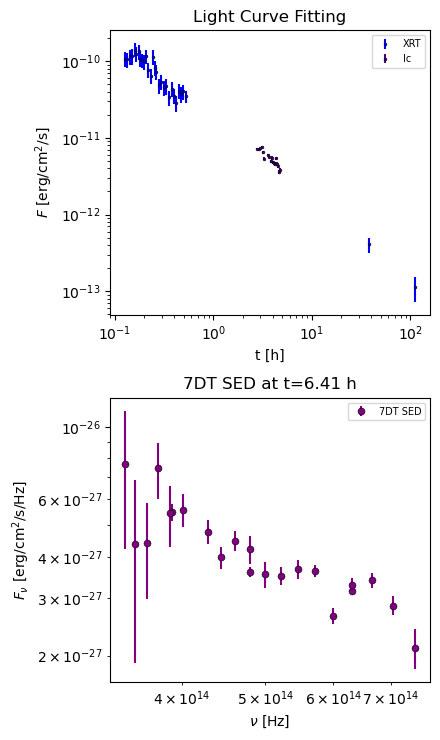

In [ ]:
draw_bestfit(save=False)


In [ ]:
def draw_bestfit(lc_model=None, spec_model=None, save=True):
    """
    lc_model     : shape [n_bands, n_t] from flux_density_grid
    spec_model   : shape [n_nu, 1] from flux_density_grid at t_spec_sec
    """
    fig = plt.figure(figsize=(4.5, 7.5))
    ax1 = fig.add_subplot(211)
    ax2 = fig.add_subplot(212)

    # ── Light-curve panel: model curves
    if lc_model is not None:
        for i, nu in enumerate(LC_BANDS):
            color, label = BAND_STYLE.get(nu, ("grey", f"{nu:.2e} Hz"))
            ax1.plot(LC_T_RANGE/3600, lc_model[i], "-", color=color, lw=1.5, label=f"model {label}")

    # Observed XRT (approximate flux density for display)
    ax1.errorbar(filtered_xrt_data["Time"]/3600, # hours
                 filtered_xrt_data["Flux"], xrt_err, # erg/cm^2/sec
                 fmt=".", color="blue", markersize=4,
                 markeredgecolor="k", markeredgewidth=0.4, label="XRT")

    # Observed optical (GCN circulars) — only bands that have a model curve
    for data in select_circular_data:
        if data.empty:
            print(f"Skipping empty data - {data}")
            continue
        wave = data["wavelength"].iloc[0]
        freq = data["frequency_Hz"].iloc[0]
        if freq not in BAND_STYLE:
            print(f"Skipping {data['Filter'].iloc[0]}/{wave:.3e} A filter - not in BAND_STYLE")
            continue
        color, label = BAND_STYLE[freq]
        ax1.errorbar(data["Time"].to_numpy(), # hours
                     mJy_to_erg_cm2_s(data["flux_mJy"].to_numpy(), freq), mJy_to_erg_cm2_s(data["flux_error_mJy"].to_numpy(), freq), # erg/cm^2/sec
                     fmt=".", color=color, markersize=4,
                     markeredgecolor="k", markeredgewidth=0.4, label=f"{label}")
        
    # ax1.set_xlim(LC_T_RANGE.min()/3600, LC_T_RANGE.max()/3600)
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    
    ax1.set_xlabel("t [h]")
    ax1.set_ylabel(r"$F$ [erg/cm$^2$/s]")
    ax1.set_title("Light Curve Fitting")
    ax1.legend(fontsize=7)

    # ── Spectrum panel
    if spec_model is not None:
        ax2.plot(SPEC_F_RANGE, spec_model[:, 0], "-", color="k", lw=1.5,
                label=f"model at t={SDT_SECONDS/3600:.2f} h")
    
    # 7DT SED
    freq = sdt_data["frequency_Hz"]
    # ax2.errorbar(freq, # Hz
    #              mJy_to_erg_cm2_s(sdt_data["flux_mJy"], freq), mJy_to_erg_cm2_s(sdt_data["flux_error_mJy"], freq), # erg/cm^2/s
    #              fmt="o", color="purple", markersize=5,
    #              markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")
    ax2.errorbar(freq, # Hz
                sdt_data["flux_mJy"] * mJy, sdt_data["flux_error_mJy"] * mJy, # erg/cm^2/s
                fmt="o", color="purple", markersize=5,
                markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")
    
    # ax2.set_xlim(SPEC_F_RANGE.min(), SPEC_F_RANGE.max())
    ax2.set_xscale("log")
    ax2.set_yscale("log")

    ax2.set_xlabel(r"$\nu$ [Hz]")   
    # ax2.set_ylabel(r"$F$ [erg/cm$^2$/s]")
    ax2.set_ylabel(r"$F_\nu$ [erg/cm$^2$/s/Hz]")
    ax2.set_title(f"7DT SED at t={SDT_SECONDS/3600:.2f} h")
    ax2.legend(fontsize=7)

    plt.tight_layout()
    if save:
        plt.savefig(f"bestfit_{_RUN_TS}_wind.png", dpi=300, bbox_inches="tight")
        print(f"Best fit plot saved as bestfit_{_RUN_TS}_wind.png")
    else:
        plt.show()

Skipping g/4.806e+03 A filter - not in BAND_STYLE
Skipping r'/6.258e+03 A filter - not in BAND_STYLE
Skipping i/7.581e+03 A filter - not in BAND_STYLE
Skipping Rc/6.534e+03 A filter - not in BAND_STYLE
Skipping V/5.538e+03 A filter - not in BAND_STYLE
Skipping J/1.235e+04 A filter - not in BAND_STYLE
Skipping clear/5.622e+03 A filter - not in BAND_STYLE


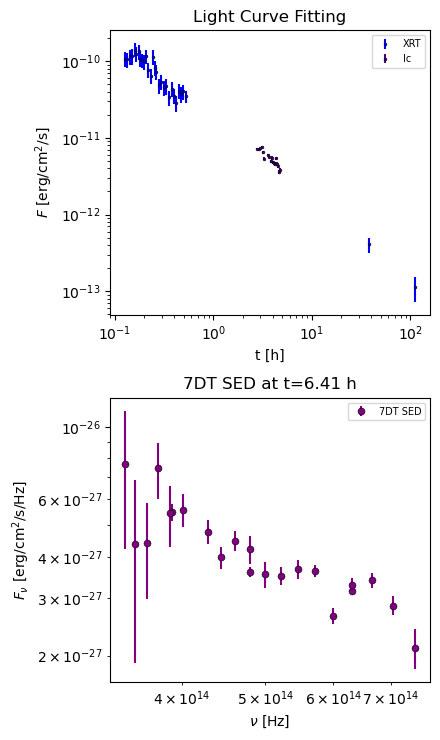

In [ ]:
draw_bestfit(save=False)


Skipping g/4806.36 A filter - not in BAND_STYLE
Skipping r'/6257.52 A filter - not in BAND_STYLE
Skipping i/7580.91 A filter - not in BAND_STYLE
Skipping Rc/6533.95 A filter - not in BAND_STYLE
Skipping V/5538.12 A filter - not in BAND_STYLE
Skipping J/12350.0 A filter - not in BAND_STYLE
Skipping clear/5622.12 A filter - not in BAND_STYLE


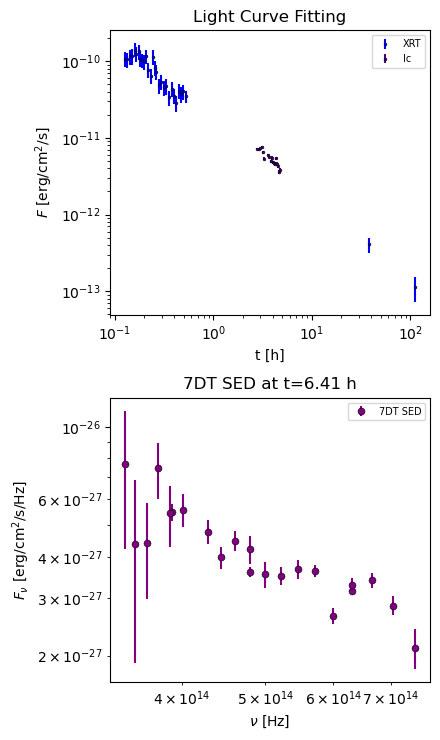

In [ ]:
# Light curve comparison
def draw_bestfit(lc_model=None, spec_model=None, save=True):
    """
    lc_model     : shape [n_bands, n_t] from flux_density_grid
    spec_model   : shape [n_nu, 1] from flux_density_grid at t_spec_sec
    """
    fig = plt.figure(figsize=(4.5, 7.5))
    ax1 = fig.add_subplot(211)
    ax2 = fig.add_subplot(212)

    # ── Light-curve panel: model curves
    if lc_model is not None:
        for i, nu in enumerate(LC_BANDS):
            color, label = BAND_STYLE.get(nu, ("grey", f"{nu:.2e} Hz"))
            ax1.plot(LC_T_RANGE/3600, lc_model[i], "-", color=color, lw=1.5, label=f"model {label}")

    # Observed XRT (approximate flux density for display)
    ax1.errorbar(filtered_xrt_data["Time"]/3600, # hours
                 filtered_xrt_data["Flux"], xrt_err, # erg/cm^2/sec
                 fmt=".", color="blue", markersize=4,
                 markeredgecolor="k", markeredgewidth=0.4, label="XRT")

    # Observed optical (GCN circulars) — only bands that have a model curve
    for data in select_circular_data:
        if data.empty:
            print(f"Skipping empty data - {data}")
            continue
        wave = data["wavelength"].iloc[0]
        freq = data["frequency_Hz"].iloc[0]
        if freq not in BAND_STYLE:
            print(f"Skipping {data['Filter'].iloc[0]}/{wave} A filter - not in BAND_STYLE")
            continue
        color, label = BAND_STYLE[freq]
        ax1.errorbar(data["Time"].to_numpy(), # hours
                     mJy_to_erg_cm2_s(data["flux_mJy"].to_numpy(), freq), mJy_to_erg_cm2_s(data["flux_error_mJy"].to_numpy(), freq), # erg/cm^2/sec
                     fmt=".", color=color, markersize=4,
                     markeredgecolor="k", markeredgewidth=0.4, label=f"{label}")
        
    # ax1.set_xlim(LC_T_RANGE.min()/3600, LC_T_RANGE.max()/3600)
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    
    ax1.set_xlabel("t [h]")
    ax1.set_ylabel(r"$F$ [erg/cm$^2$/s]")
    ax1.set_title("Light Curve Fitting")
    ax1.legend(fontsize=7)

    # ── Spectrum panel
    if spec_model is not None:
        ax2.plot(SPEC_F_RANGE, spec_model[:, 0], "-", color="k", lw=1.5,
                label=f"model at t={SDT_SECONDS/3600:.2f} h")
    
    # 7DT SED
    freq = sdt_data["frequency_Hz"]
    # ax2.errorbar(freq, # Hz
    #              mJy_to_erg_cm2_s(sdt_data["flux_mJy"], freq), mJy_to_erg_cm2_s(sdt_data["flux_error_mJy"], freq), # erg/cm^2/s
    #              fmt="o", color="purple", markersize=5,
    #              markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")
    ax2.errorbar(freq, # Hz
                sdt_data["flux_mJy"] * mJy, sdt_data["flux_error_mJy"] * mJy, # erg/cm^2/s
                fmt="o", color="purple", markersize=5,
                markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")
    
    # ax2.set_xlim(SPEC_F_RANGE.min(), SPEC_F_RANGE.max())
    ax2.set_xscale("log")
    ax2.set_yscale("log")

    ax2.set_xlabel(r"$\nu$ [Hz]")   
    # ax2.set_ylabel(r"$F$ [erg/cm$^2$/s]")
    ax2.set_ylabel(r"$F_\nu$ [erg/cm$^2$/s/Hz]")
    ax2.set_title(f"7DT SED at t={SDT_SECONDS/3600:.2f} h")
    ax2.legend(fontsize=7)

    plt.tight_layout()
    if save:
        plt.savefig(f"bestfit_{_RUN_TS}_wind.png", dpi=300, bbox_inches="tight")
        print(f"Best fit plot saved as bestfit_{_RUN_TS}_wind.png")
    else:
        plt.show()

draw_bestfit(save=False)

In [ ]:
BAND_STYLE

{2.4179892420849183e+18: ('black', 'X-ray'),
 623741163791309.9: ('teal', 'g'),
 479091489919329.1: ('crimson', 'r'),
 395457086286474.8: ('darkviolet', 'i'),
 375237762535359.3: ('indigo', 'Ic'),
 458822699898223.9: ('orangered', 'Rc'),
 541325319783608.9: ('forestgreen', 'V'),
 242746929554655.88: ('saddlebrown', 'J'),
 533237387320085.7: ('darkgrey', 'clear')}

Frequency: 623741163791309.8, Wave: 4806.36
Skipping g/4806.36 A filter - not in BAND_STYLE
Frequency: 479091489919328.94, Wave: 6257.52
Skipping r'/6257.52 A filter - not in BAND_STYLE
Frequency: 395457086286474.75, Wave: 7580.91
Skipping i/7580.91 A filter - not in BAND_STYLE
Frequency: 375237762535359.3, Wave: 7989.4
Frequency: 458822699898223.8, Wave: 6533.95
Skipping Rc/6533.95 A filter - not in BAND_STYLE
Frequency: 541325319783608.75, Wave: 5538.12
Skipping V/5538.12 A filter - not in BAND_STYLE
Frequency: 242746929554655.8, Wave: 12350.0
Skipping J/12350.0 A filter - not in BAND_STYLE
Frequency: 533237387320085.56, Wave: 5622.12
Skipping clear/5622.12 A filter - not in BAND_STYLE


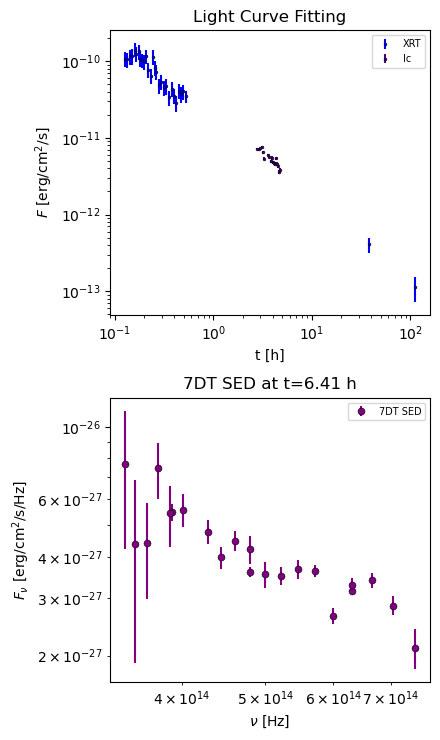

In [ ]:
# Light curve comparison
def draw_bestfit(lc_model=None, spec_model=None, save=True):
    """
    lc_model     : shape [n_bands, n_t] from flux_density_grid
    spec_model   : shape [n_nu, 1] from flux_density_grid at t_spec_sec
    """
    fig = plt.figure(figsize=(4.5, 7.5))
    ax1 = fig.add_subplot(211)
    ax2 = fig.add_subplot(212)

    # ── Light-curve panel: model curves
    if lc_model is not None:
        for i, nu in enumerate(LC_BANDS):
            color, label = BAND_STYLE.get(nu, ("grey", f"{nu:.2e} Hz"))
            ax1.plot(LC_T_RANGE/3600, lc_model[i], "-", color=color, lw=1.5, label=f"model {label}")

    # Observed XRT (approximate flux density for display)
    ax1.errorbar(filtered_xrt_data["Time"]/3600, # hours
                 filtered_xrt_data["Flux"], xrt_err, # erg/cm^2/sec
                 fmt=".", color="blue", markersize=4,
                 markeredgecolor="k", markeredgewidth=0.4, label="XRT")

    # Observed optical (GCN circulars) — only bands that have a model curve
    for data in select_circular_data:
        if data.empty:
            print(f"Skipping empty data - {data}")
            continue
        wave = data["wavelength"].iloc[0]
        freq = data["frequency_Hz"].iloc[0]
        print(f"Frequency: {freq}, Wave: {wave}")
        if freq not in BAND_STYLE:
            print(f"Skipping {data['Filter'].iloc[0]}/{wave} A filter - not in BAND_STYLE")
            continue
        color, label = BAND_STYLE[freq]
        ax1.errorbar(data["Time"].to_numpy(), # hours
                     mJy_to_erg_cm2_s(data["flux_mJy"].to_numpy(), freq), mJy_to_erg_cm2_s(data["flux_error_mJy"].to_numpy(), freq), # erg/cm^2/sec
                     fmt=".", color=color, markersize=4,
                     markeredgecolor="k", markeredgewidth=0.4, label=f"{label}")
        
    # ax1.set_xlim(LC_T_RANGE.min()/3600, LC_T_RANGE.max()/3600)
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    
    ax1.set_xlabel("t [h]")
    ax1.set_ylabel(r"$F$ [erg/cm$^2$/s]")
    ax1.set_title("Light Curve Fitting")
    ax1.legend(fontsize=7)

    # ── Spectrum panel
    if spec_model is not None:
        ax2.plot(SPEC_F_RANGE, spec_model[:, 0], "-", color="k", lw=1.5,
                label=f"model at t={SDT_SECONDS/3600:.2f} h")
    
    # 7DT SED
    freq = sdt_data["frequency_Hz"]
    # ax2.errorbar(freq, # Hz
    #              mJy_to_erg_cm2_s(sdt_data["flux_mJy"], freq), mJy_to_erg_cm2_s(sdt_data["flux_error_mJy"], freq), # erg/cm^2/s
    #              fmt="o", color="purple", markersize=5,
    #              markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")
    ax2.errorbar(freq, # Hz
                sdt_data["flux_mJy"] * mJy, sdt_data["flux_error_mJy"] * mJy, # erg/cm^2/s
                fmt="o", color="purple", markersize=5,
                markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")
    
    # ax2.set_xlim(SPEC_F_RANGE.min(), SPEC_F_RANGE.max())
    ax2.set_xscale("log")
    ax2.set_yscale("log")

    ax2.set_xlabel(r"$\nu$ [Hz]")   
    # ax2.set_ylabel(r"$F$ [erg/cm$^2$/s]")
    ax2.set_ylabel(r"$F_\nu$ [erg/cm$^2$/s/Hz]")
    ax2.set_title(f"7DT SED at t={SDT_SECONDS/3600:.2f} h")
    ax2.legend(fontsize=7)

    plt.tight_layout()
    if save:
        plt.savefig(f"bestfit_{_RUN_TS}_wind.png", dpi=300, bbox_inches="tight")
        print(f"Best fit plot saved as bestfit_{_RUN_TS}_wind.png")
    else:
        plt.show()

draw_bestfit(save=False)

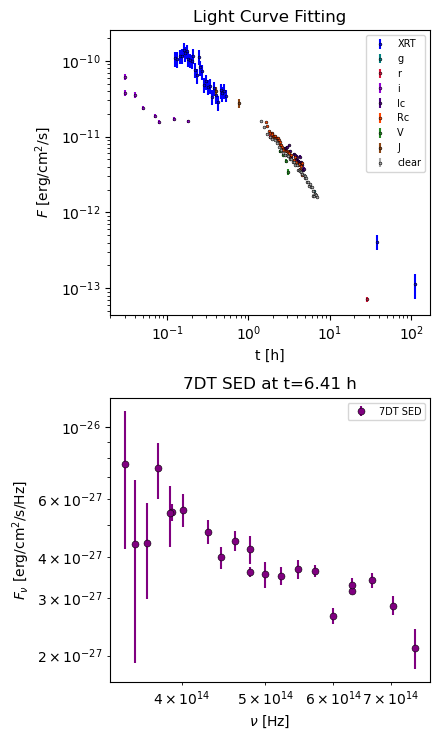

In [ ]:
# Light curve comparison
def draw_bestfit(lc_model=None, spec_model=None, save=True):
    """
    lc_model     : shape [n_bands, n_t] from flux_density_grid
    spec_model   : shape [n_nu, 1] from flux_density_grid at t_spec_sec
    """
    fig = plt.figure(figsize=(4.5, 7.5))
    ax1 = fig.add_subplot(211)
    ax2 = fig.add_subplot(212)

    # ── Light-curve panel: model curves
    if lc_model is not None:
        for i, nu in enumerate(LC_BANDS):
            color, label = BAND_STYLE.get(nu, ("grey", f"{nu:.2e} Hz"))
            ax1.plot(LC_T_RANGE/3600, lc_model[i], "-", color=color, lw=1.5, label=f"model {label}")

    # Observed XRT (approximate flux density for display)
    ax1.errorbar(filtered_xrt_data["Time"]/3600, # hours
                 filtered_xrt_data["Flux"], xrt_err, # erg/cm^2/sec
                 fmt=".", color="blue", markersize=4,
                 markeredgecolor="k", markeredgewidth=0.4, label="XRT")

    # Observed optical (GCN circulars) — only bands that have a model curve
    for data in select_circular_data:
        if data.empty:
            print(f"Skipping empty data - {data}")
            continue
        wave = data["wavelength"].iloc[0]
        freq = data["frequency_Hz"].iloc[0]
        closest_freq = min(BAND_STYLE.keys(), key=lambda k: abs(k - freq))
        
        if abs(closest_freq - freq) / freq > 0.01:
            print(f"Skipping {data['Filter'].iloc[0]}/{wave} A filter - not in BAND_STYLE")
            continue

        color, label = BAND_STYLE[closest_freq]
        ax1.errorbar(data["Time"].to_numpy(), # hours
                     mJy_to_erg_cm2_s(data["flux_mJy"].to_numpy(), closest_freq), mJy_to_erg_cm2_s(data["flux_error_mJy"].to_numpy(), closest_freq), # erg/cm^2/sec
                     fmt=".", color=color, markersize=4,
                     markeredgecolor="k", markeredgewidth=0.4, label=f"{label}")
        
    # ax1.set_xlim(LC_T_RANGE.min()/3600, LC_T_RANGE.max()/3600)
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    
    ax1.set_xlabel("t [h]")
    ax1.set_ylabel(r"$F$ [erg/cm$^2$/s]")
    ax1.set_title("Light Curve Fitting")
    ax1.legend(fontsize=7)

    # ── Spectrum panel
    if spec_model is not None:
        ax2.plot(SPEC_F_RANGE, spec_model[:, 0], "-", color="k", lw=1.5,
                label=f"model at t={SDT_SECONDS/3600:.2f} h")
    
    # 7DT SED
    freq = sdt_data["frequency_Hz"]
    # ax2.errorbar(freq, # Hz
    #              mJy_to_erg_cm2_s(sdt_data["flux_mJy"], freq), mJy_to_erg_cm2_s(sdt_data["flux_error_mJy"], freq), # erg/cm^2/s
    #              fmt="o", color="purple", markersize=5,
    #              markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")
    ax2.errorbar(freq, # Hz
                sdt_data["flux_mJy"] * mJy, sdt_data["flux_error_mJy"] * mJy, # erg/cm^2/s
                fmt="o", color="purple", markersize=5,
                markeredgecolor="k", markeredgewidth=0.4, label="7DT SED")
    
    # ax2.set_xlim(SPEC_F_RANGE.min(), SPEC_F_RANGE.max())
    ax2.set_xscale("log")
    ax2.set_yscale("log")

    ax2.set_xlabel(r"$\nu$ [Hz]")   
    # ax2.set_ylabel(r"$F$ [erg/cm$^2$/s]")
    ax2.set_ylabel(r"$F_\nu$ [erg/cm$^2$/s/Hz]")
    ax2.set_title(f"7DT SED at t={SDT_SECONDS/3600:.2f} h")
    ax2.legend(fontsize=7)

    plt.tight_layout()
    if save:
        plt.savefig(f"bestfit_{_RUN_TS}_wind.png", dpi=300, bbox_inches="tight")
        print(f"Best fit plot saved as bestfit_{_RUN_TS}_wind.png")
    else:
        plt.show()

draw_bestfit(save=False)

Connected to yp (Python 3.14.1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import warnings
from datetime import datetime
from VegasAfterglow import Fitter, ParamDef, Scale
from VegasAfterglow.units import keV, mJy, hr, sec, Hz, Jy, _c_A
from astropy.cosmology import FlatLambdaCDM
from grb.io import read_data, filter_data
from grb.utils import mJy_to_erg_cm2_s
from grb.const import REDSHIFT, RA, DEC, TRIGGER_TIME, AV, FILTER_INFO

warnings.filterwarnings('ignore', category=FutureWarning) 

In [ ]:
# ===========================================================================
## Environment setup ##
# ===========================================================================

# Constants
Z = REDSHIFT
RA = RA
DEC = DEC
T0 = TRIGGER_TIME
AV = AV
WAVELENGTH_MAP = FILTER_INFO
C_LIGHT = _c_A / 10  # Speed of light in nm per second

# Current Timestamp
_RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")

# XRT energy range
XRT_NU_MIN = 0.3 * keV  
XRT_NU_MAX = 10 * keV  
XRT_NU = 10 * keV  

# Calculate luminosity distance
cosmo = FlatLambdaCDM(H0=67.66, Om0=0.27) # Use same value from VegasAfterglow
LUMI_DIST = cosmo.luminosity_distance(Z).to('cm').value

# Generate model light curves and spectrum
LC_T_RANGE    = np.logspace(2, 6, 200)                           # 10 s → 10^6 s
SPEC_F_RANGE  = np.logspace(14, 15, 200)                         # 10^14 Hz → 10^15 Hz

# Band style for plotting
BAND_STYLE = {
    XRT_NU:                                                      ("black",       "X-ray"),
    C_LIGHT / WAVELENGTH_MAP["g"]["central_wavelength_nm"]:      ("teal",        "g"),
    C_LIGHT / WAVELENGTH_MAP["r"]["central_wavelength_nm"]:      ("crimson",     "r"),
    C_LIGHT / WAVELENGTH_MAP["i"]["central_wavelength_nm"]:      ("darkviolet",  "i"),
    C_LIGHT / WAVELENGTH_MAP["Ic"]["central_wavelength_nm"]:     ("indigo",      "Ic"),
    C_LIGHT / WAVELENGTH_MAP["Rc"]["central_wavelength_nm"]:     ("orangered",   "Rc"),
    C_LIGHT / WAVELENGTH_MAP["V"]["central_wavelength_nm"]:      ("forestgreen", "V"),
    C_LIGHT / WAVELENGTH_MAP["J"]["central_wavelength_nm"]:      ("saddlebrown", "J"),
    C_LIGHT / WAVELENGTH_MAP["clear"]["central_wavelength_nm"]:  ("darkgrey",    "clear"),
}

# Extract frequencies[Hz] from BAND_STYLE
LC_BANDS = np.array(list(BAND_STYLE.keys()))

In [ ]:
# ===========================================================================
## Model configuration ##
# ===========================================================================

# Fitter with model configuration
fitter = Fitter(
    # Source properties
    z=Z,                   # Redshift
    lumi_dist=LUMI_DIST,       # Luminosity distance [cm]

    # Model selection (see sections below for all options)
    jet="two_component",           # Jet structure type
    medium="wind",            # Ambient medium type

    # Physics options
    rvs_shock=False,           # Include reverse shock
    fwd_ssc=False,             # Forward shock inverse Compton
    rvs_ssc=False,            # Reverse shock inverse Compton
    kn=False,                  # Klein-Nishina corrections
    magnetar=False,            # Magnetar energy injection

    # Numerical parameters
    rtol=1e-5,                # Numerical tolerance
    resolution=(0.15, 0.5, 10),  # Grid resolution (phi, theta, t)
)

# Basic parameter set
params = [
    # Jet parameters
    ParamDef("E_iso",   1e50,  1e55,  Scale.log),     # Isotropic energy in erg
    ParamDef("Gamma0",   100,   500,  Scale.log),     # Lorentz factor
    ParamDef("theta_c", 0.01,   0.5,  Scale.linear),  # Opening angle in radians
    ParamDef("theta_v",    0,   0.3,  Scale.fixed),   # Viewing angle (on-axis) in radians
    
    # Medium parameters
    # ParamDef("n_ism",   1e-3,   100,  Scale.log),     # Number density in cm^-3
    
    # Wind medium parameter (replaces n_ism)
    ParamDef("A_star",  1e-3,   10,  Scale.log),     # Wind parameter
    
    # Microphysics parameters
    ParamDef("p",        2.1,   3.0,  Scale.linear),  # Electron spectral index
    ParamDef("eps_e",   1e-3,   0.5,  Scale.log),     # Electron energy fraction
    ParamDef("eps_B",   1e-5,   0.1,  Scale.log),     # Magnetic energy fraction
    ParamDef("xi_e",     0.01,   1.0,  Scale.linear),  # Fraction of accelerated electrons
    
    # Wide component
    ParamDef("E_iso_w", 1e49,  1e52,  Scale.log),     # Wide energy in erg
    ParamDef("Gamma0_w",  10,   100,  Scale.log),     # Wide Lorentz factor
    ParamDef("theta_w",  0.1,   0.5,  Scale.linear),  # Wide angle in radians
    
    # Jet duration (important for reverse shock)
    # ParamDef("tau",        1,   1e6,  Scale.log),     # Jet duration in seconds
    
    # # Reverse shock microphysics (can be different)
    # ParamDef("p_r",      2.1,   2.8,  Scale.linear),
    # ParamDef("eps_e_r", 1e-3,   0.5,  Scale.log),
    # ParamDef("eps_B_r", 1e-5,   0.1,  Scale.log),
    # ParamDef("xi_e_r",   0.1,   1.0,  Scale.linear),
    
    # Magnetar parameters (if magnetar=True)
    # ParamDef("B",        1e15,  1e16, Scale.log),     # Magnetic field strength in G
    # ParamDef("P",        0.5,   1.0,  Scale.linear),  # Period in seconds
    # ParamDef("Mdot",     1e14,  1e16, Scale.log),     # Mass accretion rate in g/s
]

In [ ]:
# ===========================================================================
## Data preparation ##
# ===========================================================================
print("=" * 50)
print("Preparing data...")
print("=" * 50)
##################### XRT lightcurve #####################
xrt_data = read_data("xrt")
# xrt_data = read_data("xrt_unabsorb")

filtered_xrt_data = filter_data(xrt_data, exclude_time_range = (3e3,  1e4)) # Exclude flare

xrt_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(filtered_xrt_data["Flux_high"], filtered_xrt_data["Flux_low"])])
# # Debug check for XRT
# xrt_zero_mask = (xrt_err == 0.0) | np.isnan(xrt_err)
# if np.any(xrt_zero_mask):
#     print(f"WARNING: Found {np.sum(xrt_zero_mask)} XRT points with 0.0 error!")
#     print(filtered_xrt_data.loc[xrt_zero_mask, ["Time", "Flux", "Flux_high", "Flux_low"]])

fitter.add_flux(band=(XRT_NU_MIN, XRT_NU_MAX),
                t=filtered_xrt_data["Time"] * sec,
                flux=filtered_xrt_data["Flux"], # erg/cm^2/s
                err=xrt_err, # erg/cm^2/s
                weights=None)  # All quantities in CGS units

# fitter.add_flux_density(nu=XRT_NU,
#                 t=filtered_xrt_data["Time"] * sec,
#                 f_nu=filtered_xrt_data["Flux"] * Jy, err=xrt_err * Jy,
#                 weights=None)  # All quantities in CGS units
print("XRT data added")

##################### 7DT SED #####################
sdt_data = read_data("sdt_pivot", correct_galactic_extinction=True, correct_host_extinction=True, 
                     host_av=AV, host_z=Z, add_converted_flux=True)
sdt_time = sdt_data["date_obs"].iloc[0]
sdt_from_t0 = datetime.strptime(sdt_time, '%Y-%m-%dT%H:%M:%S.%f') - T0
SDT_SECONDS = sdt_from_t0.total_seconds()
fitter.add_spectrum(t=SDT_SECONDS * sec, 
                    nu=sdt_data["frequency_Hz"] * Hz,
                    f_nu=sdt_data["flux_mJy"]* mJy, # erg/cm^2/s/Hz
                    err=sdt_data["flux_error_mJy"]* mJy)  # All quantities in CGS units
print("7DT SED added")

##################### GCN Circular #####################
circular_data = read_data("circular_wavelength", correct_galactic_extinction=True, correct_host_extinction=True, 
                     host_av=AV, host_z=Z, add_converted_flux=True)

select_circular_data = [
    filter_data(circular_data, filter_name="g", facility_name="7DT", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),
    filter_data(circular_data, filter_name="r'", facility_name="OHP/T193", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),
    filter_data(circular_data, filter_name="i", facility_name="NUTTelA-TAO", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),
    filter_data(circular_data, filter_name="Ic", facility_name="Leavitt", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),
    filter_data(circular_data, filter_name="Rc", facility_name="Leavitt", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),
    filter_data(circular_data, filter_name="V", facility_name="OsservatorioAstronomicoNastroVerde", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),
    filter_data(circular_data, filter_name="J", facility_name="SYSU", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),
    filter_data(circular_data, filter_name="clear", facility_name="Calapai", remove_upper_limits=True, exclude_time_range=(50, float('inf')))
]

for data in select_circular_data:
    if data.empty:
        print("Empty data, skipping...")
        continue
    # # Debug check for Optical data
    # err_array = data["flux_error_mJy"].to_numpy()
    # opt_zero_mask = (err_array == 0.0) | np.isnan(err_array)
    # if np.any(opt_zero_mask):
    #     # Using columns you likely have based on your filtering function
    #     print(f"WARNING: Found {np.sum(opt_zero_mask)} points with 0.0 error!")
    #     print(data.loc[opt_zero_mask, ["Facility","Filter","Time", "flux_mJy", "flux_error_mJy"]])
    # data_min_freq = data["frequency_Hz"].iloc[0] - data["frequency_error_Hz"].iloc[0]
    # data_max_freq = data["frequency_Hz"].iloc[0] + data["frequency_error_Hz"].iloc[0]
    # fitter.add_flux(band=(data_min_freq, data_max_freq),
    #                 t=data["Time"].to_numpy() * hr,
    #                 flux=data["flux_mJy"].to_numpy() * mJy,
    #                 err=data["flux_error_mJy"].to_numpy() * mJy,
    #                 weights=None)  # All quantities in CGS units
    
    fitter.add_flux_density(nu=data["frequency_Hz"].iloc[0],
                    t=data["Time"].to_numpy() * hr,
                    f_nu=data["flux_mJy"].to_numpy() * mJy,
                    err=data["flux_error_mJy"].to_numpy() * mJy,
                    weights=None)  # All quantities in CGS units
    print(f"GCN Circular data added for {data['Filter'].iloc[0]} filter - {len(data)} points")

Preparing data...
XRT data added
7DT SED added
GCN Circular data added for g filter - 1 points
GCN Circular data added for r' filter - 2 points
GCN Circular data added for i filter - 8 points
GCN Circular data added for Ic filter - 18 points
GCN Circular data added for Rc filter - 35 points
GCN Circular data added for V filter - 4 points
GCN Circular data added for J filter - 2 points
GCN Circular data added for clear filter - 40 points


In [ ]:
filtered_xrt_data["Time"]

0        454.429
1        481.494
2        513.174
3        543.085
4        576.041
5        600.010
6        629.154
7        654.166
8        690.257
9        721.167
10       755.220
11       793.289
12       845.170
13       879.837
14       918.815
15       952.353
16      1013.817
17      1070.422
18      1132.484
19      1203.641
20      1279.116
21      1362.483
22      1435.146
23      1523.623
24      1630.696
25      1711.160
26      1795.890
27      1896.802
43    136157.868
44    406140.614
Name: Time, dtype: float64

In [ ]:
filtered_xrt_data["Flux"]

0     1.076650e-10
1     1.051996e-10
2     1.149534e-10
3     1.156598e-10
4     1.410534e-10
5     1.251870e-10
6     1.339456e-10
7     1.068586e-10
8     1.018350e-10
9     9.894327e-11
10    1.164974e-10
11    7.665523e-11
12    6.450204e-11
13    1.131684e-10
14    8.200828e-11
15    7.278505e-11
16    4.828420e-11
17    5.391818e-11
18    4.546341e-11
19    4.726157e-11
20    3.369142e-11
21    4.349735e-11
22    3.527266e-11
23    2.826218e-11
24    4.076255e-11
25    3.734785e-11
26    4.024717e-11
27    3.473497e-11
43    4.088091e-13
44    1.138689e-13
Name: Flux, dtype: float64

In [ ]:
xrt_err

array([2.35292161e-11, 2.37817463e-11, 2.52341020e-11, 2.60239048e-11,
       2.96115107e-11, 2.73990643e-11, 2.94909093e-11, 2.41189351e-11,
       2.17727538e-11, 2.17844106e-11, 2.49076436e-11, 1.72477213e-11,
       1.45132142e-11, 2.54236249e-11, 1.84521867e-11, 1.64025325e-11,
       1.09152701e-11, 1.20940191e-11, 1.02614928e-11, 1.06009204e-11,
       7.62835272e-12, 9.54836765e-12, 7.96135494e-12, 6.37902581e-12,
       8.98812510e-12, 8.50971359e-12, 8.84805295e-12, 6.22487314e-12,
       8.97497319e-14, 4.07339239e-14])

In [ ]:
SDT_SECONDS * sec

23073.0

In [ ]:
sdt_data["frequency_Hz"] * Hz

0     6.311420e+14
1     4.796679e+14
2     3.893409e+14
3     7.475179e+14
4     7.045990e+14
5     6.657333e+14
6     6.308960e+14
7     5.996164e+14
8     5.711760e+14
9     5.452316e+14
10    5.215330e+14
11    4.998462e+14
12    4.798834e+14
13    4.614230e+14
14    4.444142e+14
15    4.284136e+14
16    4.004150e+14
17    3.867161e+14
18    3.749848e+14
19    3.635978e+14
20    3.529344e+14
21    3.428156e+14
Name: frequency_Hz, dtype: float64

In [ ]:
sdt_data["flux_mJy"]* mJy

0     3.143224e-27
1     3.609927e-27
2     5.473869e-27
3     2.115738e-27
4     2.842845e-27
5     3.393672e-27
6     3.277161e-27
7     2.644362e-27
8     3.625525e-27
9     3.674382e-27
10    3.501573e-27
11    3.546070e-27
12    4.217324e-27
13    4.487922e-27
14    3.991434e-27
15    4.785830e-27
16    5.581563e-27
17    5.432688e-27
18    7.473726e-27
19    4.400890e-27
20    4.382195e-27
21    7.706568e-27
Name: flux_mJy, dtype: float64

In [ ]:
nu=data["frequency_Hz"].iloc[0]

In [ ]:
circular_data = read_data("circular_wavelength", correct_galactic_extinction=True, correct_host_extinction=True, 
                     host_av=AV, host_z=Z, add_converted_flux=True)

In [ ]:
data =    filter_data(circular_data, filter_name="Ic", facility_name="Leavitt", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),


In [ ]:
data["frequency_Hz"].iloc[0]

TypeError: tuple indices must be integers or slices, not str

In [ ]:
data

(               Starting Date  Time Facility  magnitude  mag_error Filter  \
 78   1970-01-01 09:00:45.943  2.81  Leavitt  15.704184       0.03     Ic   
 90   1970-01-01 09:00:45.943  2.91  Leavitt  15.714184       0.03     Ic   
 100  1970-01-01 09:00:45.943  3.00  Leavitt  15.684184       0.03     Ic   
 109  1970-01-01 09:00:45.943  3.12  Leavitt  15.624184       0.03     Ic   
 116  1970-01-01 09:00:45.943  3.22  Leavitt  15.814184       0.04     Ic   
 123  1970-01-01 09:00:45.943  3.31  Leavitt  16.014184       0.04     Ic   
 139  1970-01-01 09:00:45.943  3.63  Leavitt  15.904184       0.04     Ic   
 146  1970-01-01 09:00:45.943  3.72  Leavitt  15.954184       0.04     Ic   
 151  1970-01-01 09:00:45.943  3.84  Leavitt  16.094184       0.05     Ic   
 155  1970-01-01 09:00:45.943  3.94  Leavitt  15.994184       0.05     Ic   
 159  1970-01-01 09:00:45.943  4.03  Leavitt  16.134184       0.05     Ic   
 163  1970-01-01 09:00:45.943  4.13  Leavitt  16.164184       0.05     Ic   

In [ ]:
result = data[0]["frequency_Hz"].iloc[0]
print(result)

375237762535359.3


In [ ]:
data["frequency_Hz"]

TypeError: tuple indices must be integers or slices, not str

In [ ]:
data["Time"].to_numpy() * hr

TypeError: tuple indices must be integers or slices, not str

In [ ]:
data["Time"][0]

TypeError: tuple indices must be integers or slices, not str

In [ ]:
data[0]["Time"]

78     2.81
90     2.91
100    3.00
109    3.12
116    3.22
123    3.31
139    3.63
146    3.72
151    3.84
155    3.94
159    4.03
163    4.13
168    4.25
172    4.35
176    4.44
180    4.54
186    4.66
188    4.75
Name: Time, dtype: float64

In [ ]:
data.iloc[0]

AttributeError: 'tuple' object has no attribute 'iloc'

In [ ]:
data[0]

,Starting Date,Time,Facility,magnitude,mag_error,Filter,Exposure,Circular,Limit,wavelength,filter_width,gal_extinction,gal_corrected,host_extinction_mag,host_corrected,frequency_Hz,frequency_error_Hz,flux_mJy,flux_error_mJy
78,1970-01-01 09:00:45.943,2.81,Leavitt,15.704184,0.03,Ic,NaN,42333.0,False,7989.4,1337.0,0.090892,True,0.144924,True,3.752378e+14,3.426443e+13,1.898247,0.052450
90,1970-01-01 09:00:45.943,2.91,Leavitt,15.714184,0.03,Ic,NaN,42333.0,False,7989.4,1337.0,0.090892,True,0.144924,True,3.752378e+14,3.426443e+13,1.880844,0.051970
100,1970-01-01 09:00:45.943,3.00,Leavitt,15.684184,0.03,Ic,NaN,42333.0,False,7989.4,1337.0,0.090892,True,0.144924,True,3.752378e+14,3.426443e+13,1.933538,0.053426
109,1970-01-01 09:00:45.943,3.12,Leavitt,15.624184,0.03,Ic,NaN,42333.0,False,7989.4,1337.0,0.090892,True,0.144924,True,3.752378e+14,3.426443e+13,2.043397,0.056461
116,1970-01-01 09:00:45.943,3.22,Leavitt,15.814184,0.04,Ic,NaN,42333.0,False,7989.4,1337.0,0.090892,True,0.144924,True,3.752378e+14,3.426443e+13,1.715350,0.063196
123,1970-01-01 09:00:45.943,3.31,Leavitt,16.014184,0.04,Ic,NaN,42333.0,False,7989.4,1337.0,0.090892,True,0.144924,True,3.752378e+14,3.426443e+13,1.426766,0.052564
139,1970-01-01 09:00:45.943,3.63,Leavitt,15.904184,0.04,Ic,NaN,42333.0,False,7989.4,1337.0,0.090892,True,0.144924,True,3.752378e+14,3.426443e+13,1.578893,0.058169
146,1970-01-01 09:00:45.943,3.72,Leavitt,15.954184,0.04,Ic,NaN,42333.0,False,7989.4,1337.0,0.090892,True,0.144924,True,3.752378e+14,3.426443e+13,1.507831,0.055551
151,1970-01-01 09:00:45.943,3.84,Leavitt,16.094184,0.05,Ic,NaN,42333.0,False,7989.4,1337.0,0.090892,True,0.144924,True,3.752378e+14,3.426443e+13,1.325417,0.061038
155,1970-01-01 09:00:45.943,3.94,Leavitt,15.994184,0.05,Ic,NaN,42333.0,False,7989.4,1337.0,0.090892,True,0.144924,True,3.752378e+14,3.426443e+13,1.453291,0.066927


In [ ]:
select_circular_data

[               Starting Date  Time Facility  magnitude  mag_error Filter  \
 218  1970-01-01 09:00:45.944  6.41      7DT   17.66251     0.0225      g   
 
     Exposure  Circular  Limit  wavelength  filter_width  gal_extinction  \
 218      NaN       NaN  False     4806.36       1071.48        0.194027   
 
      gal_corrected  host_extinction_mag  host_corrected  frequency_Hz  \
 218           True             0.234463            True  6.237412e+14   
 
      frequency_error_Hz  flux_mJy  flux_error_mJy  
 218        7.824697e+13  0.312624        0.006479  ,
                Starting Date   Time  Facility  magnitude  mag_error Filter  \
 30   1970-01-01 09:00:45.943   1.82  OHP/T193  15.599311       0.04     r'   
 252  1970-01-01 09:00:45.944  28.71  OHP/T193  20.969311       0.07     r'   
 
           Exposure  Circular  Limit  wavelength  filter_width  gal_extinction  \
 30             180   42266.0  False     6257.52       1264.57          0.1338   
 252  2x600 + 1x900   42276.0 

In [ ]:
    filter_data(circular_data, filter_name="g", facility_name="7DT", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),


(               Starting Date  Time Facility  magnitude  mag_error Filter  \
 218  1970-01-01 09:00:45.944  6.41      7DT   17.66251     0.0225      g   
 
     Exposure  Circular  Limit  wavelength  filter_width  gal_extinction  \
 218      NaN       NaN  False     4806.36       1071.48        0.194027   
 
      gal_corrected  host_extinction_mag  host_corrected  frequency_Hz  \
 218           True             0.234463            True  6.237412e+14   
 
      frequency_error_Hz  flux_mJy  flux_error_mJy  
 218        7.824697e+13  0.312624        0.006479  ,)

In [ ]:
circular_data = read_data("circular_wavelength", correct_galactic_extinction=True, correct_host_extinction=True, 
                     host_av=AV, host_z=Z, add_converted_flux=True)

In [ ]:
    filter_data(circular_data, filter_name="g", facility_name="7DT", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),


(               Starting Date  Time Facility  magnitude  mag_error Filter  \
 218  1970-01-01 09:00:45.944  6.41      7DT   17.66251     0.0225      g   
 
     Exposure  Circular  Limit  wavelength  filter_width  gal_extinction  \
 218      NaN       NaN  False     4806.36       1071.48        0.194027   
 
      gal_corrected  host_extinction_mag  host_corrected  frequency_Hz  \
 218           True             0.234463            True  6.237412e+14   
 
      frequency_error_Hz  flux_mJy  flux_error_mJy  
 218        7.824697e+13  0.312624        0.006479  ,)

Restarted yp (Python 3.14.1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import warnings
from datetime import datetime
from VegasAfterglow import Fitter, ParamDef, Scale
from VegasAfterglow.units import keV, mJy, hr, sec, Hz, Jy, _c_A
from astropy.cosmology import FlatLambdaCDM
from grb.io import read_data, filter_data
from grb.utils import mJy_to_erg_cm2_s
from grb.const import REDSHIFT, RA, DEC, TRIGGER_TIME, AV, FILTER_INFO

warnings.filterwarnings('ignore', category=FutureWarning) 

In [ ]:
# ===========================================================================
## Environment setup ##
# ===========================================================================

# Constants
Z = REDSHIFT
RA = RA
DEC = DEC
T0 = TRIGGER_TIME
AV = AV
WAVELENGTH_MAP = FILTER_INFO
C_LIGHT = _c_A / 10  # Speed of light in nm per second

# Current Timestamp
_RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")

# XRT energy range
XRT_NU_MIN = 0.3 * keV  
XRT_NU_MAX = 10 * keV  
XRT_NU = 10 * keV  

# Calculate luminosity distance
cosmo = FlatLambdaCDM(H0=67.66, Om0=0.27) # Use same value from VegasAfterglow
LUMI_DIST = cosmo.luminosity_distance(Z).to('cm').value

# Generate model light curves and spectrum
LC_T_RANGE    = np.logspace(2, 6, 200)                           # 10 s → 10^6 s
SPEC_F_RANGE  = np.logspace(14, 15, 200)                         # 10^14 Hz → 10^15 Hz

# Band style for plotting
BAND_STYLE = {
    XRT_NU:                                                      ("black",       "X-ray"),
    C_LIGHT / WAVELENGTH_MAP["g"]["central_wavelength_nm"]:      ("teal",        "g"),
    C_LIGHT / WAVELENGTH_MAP["r"]["central_wavelength_nm"]:      ("crimson",     "r"),
    C_LIGHT / WAVELENGTH_MAP["i"]["central_wavelength_nm"]:      ("darkviolet",  "i"),
    C_LIGHT / WAVELENGTH_MAP["Ic"]["central_wavelength_nm"]:     ("indigo",      "Ic"),
    C_LIGHT / WAVELENGTH_MAP["Rc"]["central_wavelength_nm"]:     ("orangered",   "Rc"),
    C_LIGHT / WAVELENGTH_MAP["V"]["central_wavelength_nm"]:      ("forestgreen", "V"),
    C_LIGHT / WAVELENGTH_MAP["J"]["central_wavelength_nm"]:      ("saddlebrown", "J"),
    C_LIGHT / WAVELENGTH_MAP["clear"]["central_wavelength_nm"]:  ("darkgrey",    "clear"),
}

# Extract frequencies[Hz] from BAND_STYLE
LC_BANDS = np.array(list(BAND_STYLE.keys()))

In [ ]:
# ===========================================================================
## Model configuration ##
# ===========================================================================

# Fitter with model configuration
fitter = Fitter(
    # Source properties
    z=Z,                   # Redshift
    lumi_dist=LUMI_DIST,       # Luminosity distance [cm]

    # Model selection (see sections below for all options)
    jet="two_component",           # Jet structure type
    medium="wind",            # Ambient medium type

    # Physics options
    rvs_shock=False,           # Include reverse shock
    fwd_ssc=False,             # Forward shock inverse Compton
    rvs_ssc=False,            # Reverse shock inverse Compton
    kn=False,                  # Klein-Nishina corrections
    magnetar=False,            # Magnetar energy injection

    # Numerical parameters
    rtol=1e-5,                # Numerical tolerance
    resolution=(0.15, 0.5, 10),  # Grid resolution (phi, theta, t)
)

# Basic parameter set
params = [
    # Jet parameters
    ParamDef("E_iso",   1e50,  1e55,  Scale.log),     # Isotropic energy in erg
    ParamDef("Gamma0",   100,   500,  Scale.log),     # Lorentz factor
    ParamDef("theta_c", 0.01,   0.5,  Scale.linear),  # Opening angle in radians
    ParamDef("theta_v",    0,   0.3,  Scale.fixed),   # Viewing angle (on-axis) in radians
    
    # Medium parameters
    # ParamDef("n_ism",   1e-3,   100,  Scale.log),     # Number density in cm^-3
    
    # Wind medium parameter (replaces n_ism)
    ParamDef("A_star",  1e-3,   10,  Scale.log),     # Wind parameter
    
    # Microphysics parameters
    ParamDef("p",        2.1,   3.0,  Scale.linear),  # Electron spectral index
    ParamDef("eps_e",   1e-3,   0.5,  Scale.log),     # Electron energy fraction
    ParamDef("eps_B",   1e-5,   0.1,  Scale.log),     # Magnetic energy fraction
    ParamDef("xi_e",     0.01,   1.0,  Scale.linear),  # Fraction of accelerated electrons
    
    # Wide component
    ParamDef("E_iso_w", 1e49,  1e52,  Scale.log),     # Wide energy in erg
    ParamDef("Gamma0_w",  10,   100,  Scale.log),     # Wide Lorentz factor
    ParamDef("theta_w",  0.1,   0.5,  Scale.linear),  # Wide angle in radians
    
    # Jet duration (important for reverse shock)
    # ParamDef("tau",        1,   1e6,  Scale.log),     # Jet duration in seconds
    
    # # Reverse shock microphysics (can be different)
    # ParamDef("p_r",      2.1,   2.8,  Scale.linear),
    # ParamDef("eps_e_r", 1e-3,   0.5,  Scale.log),
    # ParamDef("eps_B_r", 1e-5,   0.1,  Scale.log),
    # ParamDef("xi_e_r",   0.1,   1.0,  Scale.linear),
    
    # Magnetar parameters (if magnetar=True)
    # ParamDef("B",        1e15,  1e16, Scale.log),     # Magnetic field strength in G
    # ParamDef("P",        0.5,   1.0,  Scale.linear),  # Period in seconds
    # ParamDef("Mdot",     1e14,  1e16, Scale.log),     # Mass accretion rate in g/s
]

In [ ]:
circular_data = read_data("circular_wavelength", correct_galactic_extinction=True, correct_host_extinction=True, 
                     host_av=AV, host_z=Z, add_converted_flux=True)

In [ ]:
    filter_data(circular_data, filter_name="g", facility_name="7DT", remove_upper_limits=True, exclude_time_range=(50, float('inf'))),


(               Starting Date  Time Facility  magnitude  mag_error Filter  \
 218  1970-01-01 09:00:45.944  6.41      7DT   17.66251     0.0225      g   
 
     Exposure  Circular  Limit  wavelength  filter_width  gal_extinction  \
 218      NaN       NaN  False     4806.36       1071.48        0.194027   
 
      gal_corrected  host_extinction_mag  host_corrected  frequency_Hz  \
 218           True             0.234463            True  6.237412e+14   
 
      frequency_error_Hz  flux_mJy  flux_error_mJy  
 218        7.824697e+13  0.312624        0.006479  ,)